# Instalação

In [5]:
#Instalação
!pip install pgmpy matplotlib networkx numpy pandas

# Importações

In [6]:
# Importações necessárias
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from itertools import product
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11

# Rede Bayesiana

In [7]:
# CARREGAR A BASE

df = pd.read_csv("https://raw.githubusercontent.com/Kadson-Sousa/Trabalho-Final_IA/refs/heads/main/dados_pacientes_triagem%20(1).csv")

print("Primeiras linhas da base:")
print(df.head())
print("\nColunas da base:")
print(df.columns.tolist())

Primeiras linhas da base:
      paciente  Febre  Saturação de O₂ Pressão Arterial  Frequência Cardíaca  \
0  Paciente_01   35.5               96           110/81                   83   
1  Paciente_02   36.8               96           116/79                   69   
2  Paciente_03   35.6               98           114/72                   83   
3  Paciente_04   36.7               96           119/76                   64   
4  Paciente_05   36.2               98           110/73                   66   

   Nível de Dor  Idade  Doença Crônica  tempo de espera  
0             3     30               0              147  
1             0     28               0               87  
2             3     24               0              163  
3             2     39               0               73  
4             0     24               0              155  

Colunas da base:
['paciente', 'Febre', 'Saturação de O₂', 'Pressão Arterial', 'Frequência Cardíaca', 'Nível de Dor', 'Idade', 'Doença Crônica', 

In [8]:
# DISCRETIZAÇÃO DAS VARIÁVEIS
# FEBRE
# 0 = normal (< 37.5)
# 1 = febre moderada (37.5 a 38.9)
# 2 = febre alta (>= 39)

def categorizar_febre(temp):
    if temp < 37.5:
        return 0
    elif temp < 39:
        return 1
    else:
        return 2



# SATURAÇÃO DE O2
# 0 = normal (>= 95)
# 1 = reduzida (90 a 94)
# 2 = crítica (< 90)

def categorizar_saturacao(sat):
    if sat >= 95:
        return 0
    elif sat >= 90:
        return 1
    else:
        return 2



# PRESSÃO ARTERIAL
# Estados:
# 0 = baixa (< 90)
# 1 = normal (90 a 139)
# 2 = alta (>= 140)

def extrair_sistolica(pa):
    s = str(pa).lower().replace(" ", "")
    if "x" in s:
        parte_sistolica = s.split("x")[0]
        try:
            valor = float(parte_sistolica)
            # Se estiver em formato tipo 12x8, converte para 120
            if valor < 30:
                valor *= 10
            return valor
        except:
            return np.nan
    return np.nan

def categorizar_pressao(pa):
    sist = extrair_sistolica(pa)
    if pd.isna(sist):
        return 1
    if sist < 90:
        return 0
    elif sist < 140:
        return 1
    else:
        return 2



# FREQUÊNCIA CARDÍACA
# 0 = bradicardia (< 60)
# 1 = normal (60 a 100)
# 2 = taquicardia (> 100)

def categorizar_fc(fc):
    if fc < 60:
        return 0
    elif fc <= 100:
        return 1
    else:
        return 2



# NÍVEL DE DOR
# 0 = leve (0 a 3)
# 1 = moderada (4 a 6)
# 2 = intensa (7 a 10)

def categorizar_dor(dor):
    if dor <= 3:
        return 0
    elif dor <= 6:
        return 1
    else:
        return 2



# IDADE
# 0 = < 60
# 1 = >= 60

def categorizar_idade(idade):
    return 0 if idade < 60 else 1



# DOENÇA CRÔNICA
# já está binária no CSV:
# 0 = não
# 1 = sim

# Aplicar discretização
df['Febre_cat'] = df['Febre'].apply(categorizar_febre)
df['Saturacao_cat'] = df['Saturação de O₂'].apply(categorizar_saturacao)
df['Pressao_cat'] = df['Pressão Arterial'].apply(categorizar_pressao)
df['FC_cat'] = df['Frequência Cardíaca'].apply(categorizar_fc)
df['Dor_cat'] = df['Nível de Dor'].apply(categorizar_dor)
df['Idade_cat'] = df['Idade'].apply(categorizar_idade)
df['Cronica_cat'] = df['Doença Crônica'].astype(int)

print("\nBase discretizada (amostra):")
print(df[['paciente','Febre_cat','Saturacao_cat','Pressao_cat','FC_cat','Dor_cat','Idade_cat','Cronica_cat']].head())


Base discretizada (amostra):
      paciente  Febre_cat  Saturacao_cat  Pressao_cat  FC_cat  Dor_cat  \
0  Paciente_01          0              0            1       1        0   
1  Paciente_02          0              0            1       1        0   
2  Paciente_03          0              0            1       1        0   
3  Paciente_04          0              0            1       1        0   
4  Paciente_05          0              0            1       1        0   

   Idade_cat  Cronica_cat  
0          0            0  
1          0            0  
2          0            0  
3          0            0  
4          0            0  


In [9]:
# DEFINIR A ESTRUTURA DA REDE


modelo_triagem = DiscreteBayesianNetwork([
    ('Febre_cat', 'Gravidade'),
    ('Saturacao_cat', 'Gravidade'),
    ('Pressao_cat', 'Gravidade'),
    ('FC_cat', 'Gravidade'),
    ('Dor_cat', 'Gravidade'),
    ('Idade_cat', 'Gravidade'),
    ('Cronica_cat', 'Gravidade')
])

print("\nEstrutura da rede criada!")
print("Nós:", list(modelo_triagem.nodes()))
print("Arestas:", list(modelo_triagem.edges()))


Estrutura da rede criada!
Nós: ['Febre_cat', 'Gravidade', 'Saturacao_cat', 'Pressao_cat', 'FC_cat', 'Dor_cat', 'Idade_cat', 'Cronica_cat']
Arestas: [('Febre_cat', 'Gravidade'), ('Saturacao_cat', 'Gravidade'), ('Pressao_cat', 'Gravidade'), ('FC_cat', 'Gravidade'), ('Dor_cat', 'Gravidade'), ('Idade_cat', 'Gravidade'), ('Cronica_cat', 'Gravidade')]


In [10]:
# CPTs DAS VARIÁVEIS DE ENTRADA

def cpd_from_counts(nome_coluna, variable_card):
    probs = df[nome_coluna].value_counts(normalize=True).sort_index()

    values = []
    for i in range(variable_card):
        values.append([probs.get(i, 0.0)])

    return TabularCPD(
        variable=nome_coluna,
        variable_card=variable_card,
        values=values
    )

cpd_febre = cpd_from_counts('Febre_cat', 3)
cpd_saturacao = cpd_from_counts('Saturacao_cat', 3)
cpd_pressao = cpd_from_counts('Pressao_cat', 3)
cpd_fc = cpd_from_counts('FC_cat', 3)
cpd_dor = cpd_from_counts('Dor_cat', 3)
cpd_idade = cpd_from_counts('Idade_cat', 2)
cpd_cronica = cpd_from_counts('Cronica_cat', 2)

print("\nCPTs das variáveis de entrada criadas a partir da base.")


CPTs das variáveis de entrada criadas a partir da base.


In [11]:
# CPT DE GRAVIDADE

# Gravidade:
# 0 = baixa
# 1 = média
# 2 = alta
#
# Pais:
# - Febre_cat (3)
# - Saturacao_cat (3)
# - Pressao_cat (3)
# - FC_cat (3)
# - Dor_cat (3)
# - Idade_cat (2)
# - Cronica_cat (2)
#
# Total de combinações:
# 3 * 3 * 3 * 3 * 3 * 2 * 2 = 972
#
# Vamos gerar a CPT programaticamente com base em um score clínico plausível.

valores_baixa = []
valores_media = []
valores_alta = []

# Pesos clínicos plausíveis
# - Saturação crítica pesa muito
# - Pressão baixa pesa muito
# - FC alterada aumenta risco
# - Febre alta aumenta
# - Dor intensa aumenta, mas menos que sinais vitais
# - Idoso e doença crônica aumentam o risco final

peso_febre = {
    0: 0,   # normal
    1: 1,   # febre moderada
    2: 2    # febre alta
}

peso_sat = {
    0: 0,   # normal
    1: 3,   # reduzida
    2: 6    # crítica
}

peso_pa = {
    0: 4,   # baixa
    1: 0,   # normal
    2: 1    # alta
}

peso_fc = {
    0: 2,   # bradicardia
    1: 0,   # normal
    2: 2    # taquicardia
}

peso_dor = {
    0: 0,   # leve
    1: 1,   # moderada
    2: 2    # intensa
}

peso_idade = {
    0: 0,   # < 60
    1: 2    # >= 60
}

peso_cronica = {
    0: 0,   # não
    1: 2    # sim
}

# Gerar a CPT de Gravidade para todas as combinações possíveis
for febre, sat, pa, fc, dor, idade, cronica in product(
    range(3), range(3), range(3), range(3), range(3), range(2), range(2)
):
    score = (
        peso_febre[febre] +
        peso_sat[sat] +
        peso_pa[pa] +
        peso_fc[fc] +
        peso_dor[dor] +
        peso_idade[idade] +
        peso_cronica[cronica]
    )

    # Converter score em probabilidades
    # Quanto maior o score, maior a chance de gravidade alta.
    if score <= 2:
        p_baixa, p_media, p_alta = 0.85, 0.13, 0.02
    elif score <= 4:
        p_baixa, p_media, p_alta = 0.60, 0.30, 0.10
    elif score <= 6:
        p_baixa, p_media, p_alta = 0.30, 0.45, 0.25
    elif score <= 8:
        p_baixa, p_media, p_alta = 0.12, 0.38, 0.50
    elif score <= 10:
        p_baixa, p_media, p_alta = 0.05, 0.25, 0.70
    else:
        p_baixa, p_media, p_alta = 0.02, 0.13, 0.85

    valores_baixa.append(p_baixa)
    valores_media.append(p_media)
    valores_alta.append(p_alta)

cpd_gravidade = TabularCPD(
    variable='Gravidade',
    variable_card=3,
    values=[valores_baixa, valores_media, valores_alta],
    evidence=['Febre_cat', 'Saturacao_cat', 'Pressao_cat', 'FC_cat', 'Dor_cat', 'Idade_cat', 'Cronica_cat'],
    evidence_card=[3, 3, 3, 3, 3, 2, 2]
)

print("CPT de Gravidade criada programaticamente.")

CPT de Gravidade criada programaticamente.


In [12]:
# ADICIONAR CPTs AO MODELO

modelo_triagem.add_cpds(
    cpd_febre,
    cpd_saturacao,
    cpd_pressao,
    cpd_fc,
    cpd_dor,
    cpd_idade,
    cpd_cronica,
    cpd_gravidade
)

print("\nValidação do modelo:", modelo_triagem.check_model())


Validação do modelo: True


In [13]:
# VISUALIZAR ALGUMAS CPTs

print("\n=== CPT de Febre ===")
print(cpd_febre)

print("\n=== CPT de Saturação ===")
print(cpd_saturacao)

print("\n=== CPT de Pressão ===")
print(cpd_pressao)

print("\n=== CPT de Frequência Cardíaca ===")
print(cpd_fc)

print("\n=== CPT de Dor ===")
print(cpd_dor)

print("\n=== CPT de Idade ===")
print(cpd_idade)

print("\n=== CPT de Doença Crônica ===")
print(cpd_cronica)

print("\n=== CPT de Gravidade ===")
print("A CPT de Gravidade possui 972 combinações de evidência.")


=== CPT de Febre ===
+--------------+--------+
| Febre_cat(0) | 0.7375 |
+--------------+--------+
| Febre_cat(1) | 0.175  |
+--------------+--------+
| Febre_cat(2) | 0.0875 |
+--------------+--------+

=== CPT de Saturação ===
+------------------+--------+
| Saturacao_cat(0) | 0.6375 |
+------------------+--------+
| Saturacao_cat(1) | 0.2625 |
+------------------+--------+
| Saturacao_cat(2) | 0.1    |
+------------------+--------+

=== CPT de Pressão ===
+----------------+---+
| Pressao_cat(0) | 0 |
+----------------+---+
| Pressao_cat(1) | 1 |
+----------------+---+
| Pressao_cat(2) | 0 |
+----------------+---+

=== CPT de Frequência Cardíaca ===
+-----------+------+
| FC_cat(0) | 0    |
+-----------+------+
| FC_cat(1) | 0.75 |
+-----------+------+
| FC_cat(2) | 0.25 |
+-----------+------+

=== CPT de Dor ===
+------------+--------+
| Dor_cat(0) | 0.5625 |
+------------+--------+
| Dor_cat(1) | 0.2625 |
+------------+--------+
| Dor_cat(2) | 0.175  |
+------------+--------+

===

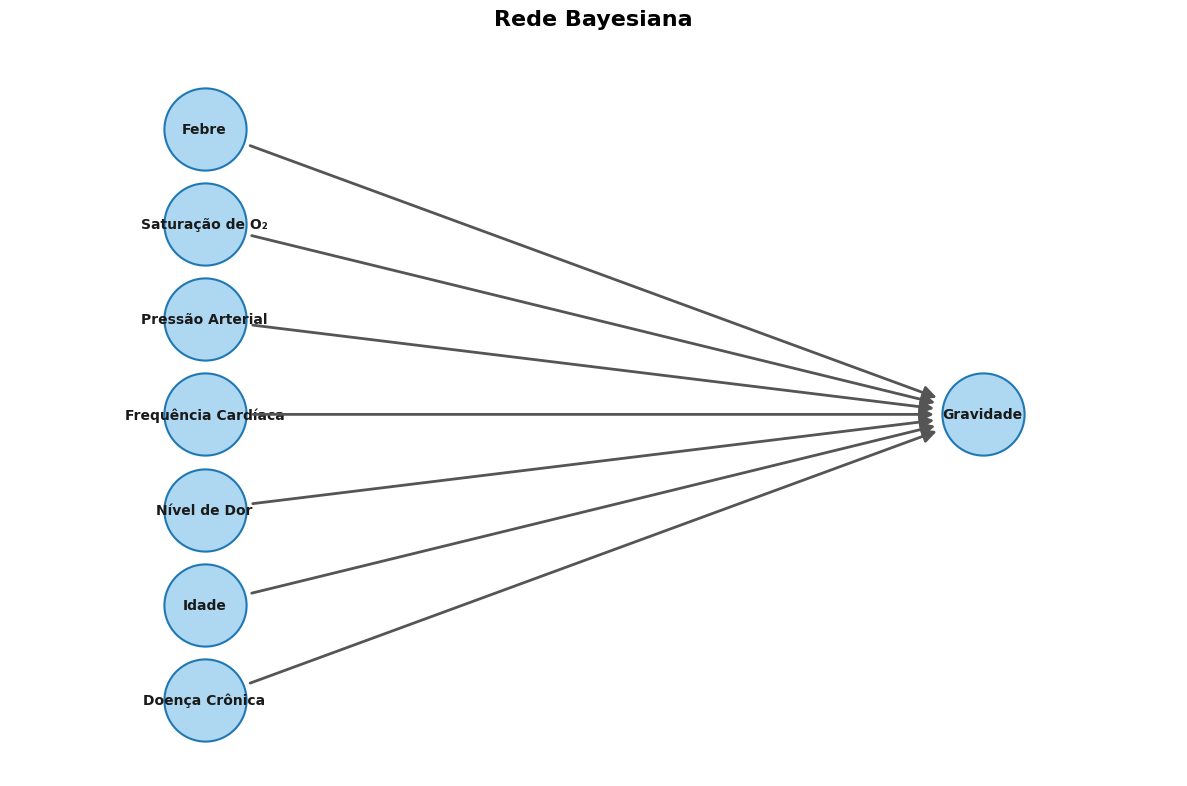

In [14]:
# VISUALIZAR A REDE

import matplotlib.pyplot as plt
import networkx as nx

# 1. Definir os nós e as arestas da rede
nos = [
    'Febre', 'Saturação de O₂', 'Pressão Arterial',
    'Frequência Cardíaca', 'Nível de Dor', 'Idade', 'Doença Crônica', 'Gravidade'
]

arestas = [
    ('Febre', 'Gravidade'),
    ('Saturação de O₂', 'Gravidade'),
    ('Pressão Arterial', 'Gravidade'),
    ('Frequência Cardíaca', 'Gravidade'),
    ('Nível de Dor', 'Gravidade'),
    ('Idade', 'Gravidade'),
    ('Doença Crônica', 'Gravidade')
]

G = nx.DiGraph()
G.add_nodes_from(nos)
G.add_edges_from(arestas)

# 2. FIXAR AS COORDENADAS (X, Y) MANUALMENTE PARA SIMETRIA PERFEITA
# Coluna da Esquerda (X = 0): Entradas distribuídas uniformemente na vertical (Y de 3 a -3)
# Coluna da Direita (X = 2): Gravidade centralizada no meio exato (Y = 0)
pos = {
    'Febre':     (0,  3),
    'Saturação de O₂': (0,  2),
    'Pressão Arterial':   (0,  1),
    'Frequência Cardíaca':        (0,  0),
    'Nível de Dor':       (0, -1),
    'Idade':     (0, -2),
    'Doença Crônica':   (0, -3),
    'Gravidade':     (2,  0)  # O alvo centralizado
}

# 3. Configurar a janela do Matplotlib
fig, ax = plt.subplots(figsize=(12, 8))

# 4. Desenhar os nós
nx.draw_networkx_nodes(
    G,
    pos,
    node_color='#aed8f2',
    node_size=3500,        # Aumentado um pouco para acomodar melhor o texto
    edgecolors='#1f77b4',
    linewidths=1.5,
    ax=ax
)

# 5. Desenhar as etiquetas de texto
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight='bold',
    font_color='#1a1a1a',
    ax=ax
)

# 6. Desenhar as setas direcionadas simétricas
for pai, filho in G.edges():
    x_pai, y_pai = pos[pai]
    x_filho, y_filho = pos[filho]

    ax.annotate(
        "",
        xy=(x_filho, y_filho),
        xytext=(x_pai, y_pai),
        arrowprops=dict(
            arrowstyle="-|>",
            color="#555555",
            lw=2.0,
            mutation_scale=20,
            shrinkA=35,        # Margem de recuo baseada no tamanho do nó
            shrinkB=35         # Garante que a ponta toque perfeitamente a borda
        )
    )

# 7. Margens limpas e simétricas nas bordas do gráfico
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-3.8, 3.8)

# Ocultar eixos e exibir
ax.set_axis_off()
plt.title("Rede Bayesiana", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [15]:
# INFERÊNCIA

inferencia_triagem = VariableElimination(modelo_triagem)

# EXEMPLO 1: Probabilidade de Gravidade sem evidências

resultado = inferencia_triagem.query(variables=['Gravidade'])
print("\nP(Gravidade):")
print(resultado)


# EXEMPLO 2: Paciente com febre alta, saturação reduzida,
# pressão baixa, dor intensa, idoso e com doença crônica

resultado = inferencia_triagem.query(
    variables=['Gravidade'],
    evidence={
        'Febre_cat': 2,       # febre alta
        'Saturacao_cat': 1,   # reduzida
        'Pressao_cat': 0,     # baixa
        'Dor_cat': 2,         # intensa
        'Idade_cat': 1,       # idoso
        'Cronica_cat': 1      # diabético / doença crônica
    }
)
print("\nP(Gravidade | febre alta, sat reduzida, PA baixa, dor intensa, idoso, crônico):")
print(resultado)


# EXEMPLO 3: Paciente jovem, sem doença crônica,
# sinais normais e dor leve

resultado = inferencia_triagem.query(
    variables=['Gravidade'],
    evidence={
        'Febre_cat': 0,
        'Saturacao_cat': 0,
        'Pressao_cat': 1,
        'FC_cat': 1,
        'Dor_cat': 0,
        'Idade_cat': 0,
        'Cronica_cat': 0
    }
)
print("\nP(Gravidade | quadro leve):")
print(resultado)


P(Gravidade):
+--------------+------------------+
| Gravidade    |   phi(Gravidade) |
+==============+==================+
| Gravidade(0) |           0.5718 |
+--------------+------------------+
| Gravidade(1) |           0.2632 |
+--------------+------------------+
| Gravidade(2) |           0.1650 |
+--------------+------------------+

P(Gravidade | febre alta, sat reduzida, PA baixa, dor intensa, idoso, crônico):
+--------------+------------------+
| Gravidade    |   phi(Gravidade) |
+==============+==================+
| Gravidade(0) |           0.0200 |
+--------------+------------------+
| Gravidade(1) |           0.1300 |
+--------------+------------------+
| Gravidade(2) |           0.8500 |
+--------------+------------------+

P(Gravidade | quadro leve):
+--------------+------------------+
| Gravidade    |   phi(Gravidade) |
+==============+==================+
| Gravidade(0) |           0.8500 |
+--------------+------------------+
| Gravidade(1) |           0.1300 |
+----------

In [16]:
# FUNÇÃO PARA CONSULTAR UM PACIENTE DA BASE

def consultar_paciente(indice):
    linha = df.iloc[indice]

    evidencias = {
        'Febre_cat': linha['Febre_cat'],
        'Saturacao_cat': linha['Saturacao_cat'],
        'Pressao_cat': linha['Pressao_cat'],
        'FC_cat': linha['FC_cat'],
        'Dor_cat': linha['Dor_cat'],
        'Idade_cat': linha['Idade_cat'],
        'Cronica_cat': linha['Cronica_cat']
    }

    resultado = inferencia_triagem.query(
        variables=['Gravidade'],
        evidence=evidencias
    )

    print(f"\nPaciente: {linha['paciente']}")
    print("Evidências usadas:", evidencias)
    print(resultado)

# Exemplo: consultar o primeiro paciente da base
consultar_paciente(0)


Paciente: Paciente_01
Evidências usadas: {'Febre_cat': np.int64(0), 'Saturacao_cat': np.int64(0), 'Pressao_cat': np.int64(1), 'FC_cat': np.int64(1), 'Dor_cat': np.int64(0), 'Idade_cat': np.int64(0), 'Cronica_cat': np.int64(0)}
+--------------+------------------+
| Gravidade    |   phi(Gravidade) |
+==============+==================+
| Gravidade(0) |           0.8500 |
+--------------+------------------+
| Gravidade(1) |           0.1300 |
+--------------+------------------+
| Gravidade(2) |           0.0200 |
+--------------+------------------+


# Algoritmo de Busca (A*)

In [17]:
# CLASSE PACIENTE

class Paciente:
    def __init__(self, nome, p_alta, tempo_espera, tempo_atendimento=10):
        self.nome = nome
        self.p_alta = p_alta
        self.tempo_espera = tempo_espera
        self.tempo_atendimento = tempo_atendimento

    def calcular_risco_atual(self):
        return self.p_alta * self.tempo_espera

    def clonar_com_tempo_adicional(self, minutos):
        return Paciente(
            self.nome,
            self.p_alta,
            self.tempo_espera + minutos,
            self.tempo_atendimento
        )

    def __repr__(self):
        return f"[{self.nome} | P(Alta)={self.p_alta:.2f} | Espera={self.tempo_espera}min]"


In [18]:
# GERAR PACIENTES DA FILA A PARTIR DA REDE BAYESIANA

def gerar_pacientes_para_fila(df, inferencia_triagem, n=25):
    lista_pacientes = []

    for i in range(n):
        linha = df.iloc[i]

        evidencias = {
            'Febre_cat': int(linha['Febre_cat']),
            'Saturacao_cat': int(linha['Saturacao_cat']),
            'Pressao_cat': int(linha['Pressao_cat']),
            'FC_cat': int(linha['FC_cat']),
            'Dor_cat': int(linha['Dor_cat']),
            'Idade_cat': int(linha['Idade_cat']),
            'Cronica_cat': int(linha['Cronica_cat'])
        }

        resultado = inferencia_triagem.query(
            variables=['Gravidade'],
            evidence=evidencias
        )

        # Índice 2 = Gravidade alta
        p_alta = float(resultado.values[2])

        paciente = Paciente(
            nome=linha['paciente'],
            p_alta=p_alta,
            tempo_espera=int(linha['tempo de espera'])
        )

        lista_pacientes.append(paciente)

    return lista_pacientes

In [19]:
# ESTADO DO A*

class EstadoAEstrela:
    def __init__(self, pacientes_restantes, ordem_atendimento=None, g_custo=0):
        self.pacientes_restantes = pacientes_restantes
        self.ordem_atendimento = ordem_atendimento if ordem_atendimento is not None else []
        self.g_custo = g_custo

        # h(n): soma dos riscos atuais dos pacientes restantes
        self.h_heuristica = sum(p.calcular_risco_atual() for p in self.pacientes_restantes)

        # f(n) = g(n) + h(n)
        self.f_total = self.g_custo + self.h_heuristica

    def __lt__(self, outro):
        return self.f_total < outro.f_total


# CHAVE ÚNICA DO ESTADO

def chave_estado(pacientes_restantes):
    return tuple(
        sorted(
            (
                p.nome,
                round(p.p_alta, 6),
                round(p.tempo_espera, 6),
                round(p.tempo_atendimento, 6)
            )
            for p in pacientes_restantes
        )
    )


In [20]:
# A*

def simular_a_estrela_classico(lista_pacientes):
    estado_inicial = EstadoAEstrela(pacientes_restantes=lista_pacientes)

    fronteira = []
    heapq.heappush(fronteira, estado_inicial)

    melhor_g = {}
    melhor_g[chave_estado(estado_inicial.pacientes_restantes)] = 0

    while fronteira:
        atual = heapq.heappop(fronteira)

        if not atual.pacientes_restantes:
            return atual.ordem_atendimento, atual.g_custo

        chave_atual = chave_estado(atual.pacientes_restantes)

        if atual.g_custo > melhor_g.get(chave_atual, float("inf")):
            continue

        for i, paciente_escolhido in enumerate(atual.pacientes_restantes):
            proximos_restantes = [
                p for j, p in enumerate(atual.pacientes_restantes) if j != i
            ]

            # custo da ação = risco acumulado de quem ficou esperando
            custo_acao = sum(p.calcular_risco_atual() for p in proximos_restantes)

            # atualiza o tempo de espera de quem ficou na fila
            restantes_atualizados = [
                p.clonar_com_tempo_adicional(paciente_escolhido.tempo_atendimento)
                for p in proximos_restantes
            ]

            novo_g = atual.g_custo + custo_acao

            novo_estado = EstadoAEstrela(
                pacientes_restantes=restantes_atualizados,
                ordem_atendimento=atual.ordem_atendimento + [paciente_escolhido.nome],
                g_custo=novo_g
            )

            chave_nova = chave_estado(novo_estado.pacientes_restantes)

            if novo_g < melhor_g.get(chave_nova, float("inf")):
                melhor_g[chave_nova] = novo_g
                heapq.heappush(fronteira, novo_estado)

    return [], float("inf")


# FIFO

def simular_fifo(lista_pacientes):
    fila = sorted(lista_pacientes, key=lambda p: p.tempo_espera, reverse=True)
    ordem = []
    custo_total = 0

    while fila:
        atendido = fila.pop(0)
        ordem.append(atendido.nome)

        custo_total += sum(p.calcular_risco_atual() for p in fila)
        fila = [p.clonar_com_tempo_adicional(atendido.tempo_atendimento) for p in fila]

    return ordem, custo_total


# GULOSA

def simular_gulosa(lista_pacientes):
    fila = sorted(lista_pacientes, key=lambda p: p.p_alta, reverse=True)
    ordem = []
    custo_total = 0

    while fila:
        atendido = fila.pop(0)
        ordem.append(atendido.nome)

        custo_total += sum(p.calcular_risco_atual() for p in fila)
        fila = [p.clonar_com_tempo_adicional(atendido.tempo_atendimento) for p in fila]

    return ordem, custo_total

In [21]:
# AMBIENTE DE EXPERIMENTOS

def executar_experimento(cenario_nome, pacientes):
    print(f"\n" + "=" * 60)
    print(f" EXECUÇÃO: {cenario_nome} ({len(pacientes)} Pacientes)")
    print("=" * 60)

    ordem_fifo, custo_fifo = simular_fifo(pacientes)
    ordem_gulosa, custo_gulosa = simular_gulosa(pacientes)
    ordem_aste, custo_aste = simular_a_estrela_classico(pacientes)

    dados_resultado = {
        "Estratégia": [
            "FIFO (Chegada)",
            "Gulosa (Gravidade)",
            "Algoritmo A* Clássico"
        ],
        "Ordem de Atendimento": [
            ", ".join(ordem_fifo[:5]) + ("..." if len(ordem_fifo) > 5 else ""),
            ", ".join(ordem_gulosa[:5]) + ("..." if len(ordem_gulosa) > 5 else ""),
            ", ".join(ordem_aste[:5]) + ("..." if len(ordem_aste) > 5 else "")
        ],
        "Risco Acumulado Total": [
            f"{custo_fifo:.2f}",
            f"{custo_gulosa:.2f}",
            f"{custo_aste:.2f}"
        ]
    }

    df_res = pd.DataFrame(dados_resultado)
    print(df_res.to_string(index=False))

    if custo_aste <= min(custo_fifo, custo_gulosa):
        print("\n✅ Validação: o A* encontrou a menor solução entre as estratégias comparadas.")
    else:
        print("\n⚠️ Observação: o A* não ficou abaixo das heurísticas comparadas neste cenário.")

In [22]:
# ============================================================
# GERAR CENÁRIOS A PARTIR DA BASE REAL
# ============================================================

# Cenário pequeno: primeiros 6 pacientes da base
cenario_pequeno = gerar_pacientes_para_fila(df, inferencia_triagem, n=6)

# Cenário médio: primeiros 25 pacientes da base
cenario_medio = gerar_pacientes_para_fila(df, inferencia_triagem, n=25)


# ============================================================
# EXECUÇÃO DO CENÁRIO PEQUENO (COM A*)
# ============================================================
executar_experimento("Cenário Pequeno", cenario_pequeno)


# ============================================================
# EXECUÇÃO DO CENÁRIO MÉDIO (SEM A*, PARA NÃO EXPLODIR)
# ============================================================
print(f"\n" + "=" * 60)
print(f" EXECUÇÃO: Cenário Médio ({len(cenario_medio)} Pacientes)")
print("=" * 60)

ordem_fifo, custo_fifo = simular_fifo(cenario_medio)
ordem_gulosa, custo_gulosa = simular_gulosa(cenario_medio)

dados_resultado_medio = {
    "Estratégia": [
        "FIFO (Chegada)",
        "Gulosa (Gravidade)",
        "Algoritmo A* Clássico"
    ],
    "Ordem de Atendimento": [
        ", ".join(ordem_fifo[:5]) + ("..." if len(ordem_fifo) > 5 else ""),
        ", ".join(ordem_gulosa[:5]) + ("..." if len(ordem_gulosa) > 5 else ""),
        "Não executado"
    ],
    "Risco Acumulado Total": [
        f"{custo_fifo:.2f}",
        f"{custo_gulosa:.2f}",
        "-"
    ]
}

df_res_medio = pd.DataFrame(dados_resultado_medio)
print(df_res_medio.to_string(index=False))

print("\nA* não executado neste cenário.")
print("Motivo: crescimento fatorial do espaço de busca com 25 pacientes.")


 EXECUÇÃO: Cenário Pequeno (6 Pacientes)
           Estratégia                                               Ordem de Atendimento Risco Acumulado Total
       FIFO (Chegada) Paciente_03, Paciente_05, Paciente_01, Paciente_06, Paciente_02...                 35.94
   Gulosa (Gravidade) Paciente_01, Paciente_02, Paciente_03, Paciente_04, Paciente_05...                 43.54
Algoritmo A* Clássico Paciente_03, Paciente_05, Paciente_01, Paciente_06, Paciente_02...                 35.94

✅ Validação: o A* encontrou a menor solução entre as estratégias comparadas.

 EXECUÇÃO: Cenário Médio (25 Pacientes)
           Estratégia                                               Ordem de Atendimento Risco Acumulado Total
       FIFO (Chegada) Paciente_03, Paciente_10, Paciente_05, Paciente_20, Paciente_01...              11605.99
   Gulosa (Gravidade) Paciente_08, Paciente_17, Paciente_15, Paciente_16, Paciente_22...               1688.26
Algoritmo A* Clássico                                         